Mounted at /content/drive


In [ ]:
!pip install tensorflow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Dense, Activation,Dropout,Conv2D, MaxPooling2D,BatchNormalization, Flatten, Add, AveragePooling2D, Input, ZeroPadding2D
from tensorflow.keras.layers import Activation, BatchNormalization, Add, Reshape, DepthwiseConv2D, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras import regularizers
from tensorflow.keras.initializers import glorot_uniform
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model, load_model, Sequential
import numpy as np
import pandas as pd
import shutil
import time
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow
import os
import seaborn as sns
sns.set_style('darkgrid')
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.metrics import Recall, Precision, AUC, RootMeanSquaredError
from sklearn.metrics import f1_score

In [ ]:
data_dir = "/train_data"

In [ ]:
filepaths = []
labels = []
for root, dirs, files in os.walk(data_dir):
    for klass in dirs:
        classpath = os.path.join(root, klass)
        flist = os.listdir(classpath)
        for f in flist:
            fpath = os.path.join(classpath, f)
            filepaths.append(fpath)
            labels.append(klass)

Fseries = pd.Series(filepaths, name='filepaths')
Lseries = pd.Series(labels, name='labels')
data_df = pd.concat([Fseries, Lseries], axis=1)
df = data_df.reset_index(drop=True)

print(df['labels'].value_counts())

labels
cycling               1000
dancing               1000
fighting              1000
listening_to_music    1000
running               1000
eating                 952
Name: count, dtype: int64


In [ ]:
sample_size=952
sample_list=[]
group=df.groupby('labels')
for label in df['labels'].unique():
    label_group=group.get_group(label).sample(sample_size, replace=False, random_state=123, axis=0)
    sample_list.append(label_group)
df=pd.concat(sample_list, axis=0).reset_index(drop=True)
print (len(df))

5712


In [ ]:
train_split=.8
test_split=.1
dummy_split=test_split/(1-train_split)
train_df, dummy_df=train_test_split(df, train_size=train_split, shuffle=True, random_state=123)
test_df, valid_df=train_test_split(dummy_df, train_size=dummy_split, shuffle=True, random_state=123)
print ('train_df length: ', len(train_df), ' test_df length: ', len(test_df), '  valid_df length: ', len(valid_df))

train_df length:  4569  test_df length:  571   valid_df length:  572


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
height=224
width=224
channels=3
batch_size=32
img_shape=(height, width, channels)
img_size=(height, width)
length=len(test_df)
test_batch_size=sorted([int(length/n) for n in range(1,length+1) if length % n ==0 and length/n<=80],reverse=True)[0]
test_steps=int(length/test_batch_size)
print ( 'test batch size: ' ,test_batch_size, '  test steps: ', test_steps)
def scalar(img):
    return img/127.5-1  # scale pixel between -1 and +1
gen=ImageDataGenerator(preprocessing_function=scalar)
train_gen=gen.flow_from_dataframe( train_df, x_col='filepaths', y_col='labels', target_size=img_size, class_mode='categorical',
                                    color_mode='rgb', shuffle=True, batch_size=batch_size)
test_gen=gen.flow_from_dataframe( test_df, x_col='filepaths', y_col='labels', target_size=img_size, class_mode='categorical',
                                    color_mode='rgb', shuffle=False, batch_size=test_batch_size)
valid_gen=gen.flow_from_dataframe( valid_df, x_col='filepaths', y_col='labels', target_size=img_size, class_mode='categorical',
                                    color_mode='rgb', shuffle=True, batch_size=batch_size)
classes=list(train_gen.class_indices.keys())
class_count=len(classes)

test batch size:  1   test steps:  571
Found 4569 validated image filenames belonging to 6 classes.
Found 571 validated image filenames belonging to 6 classes.
Found 572 validated image filenames belonging to 6 classes.


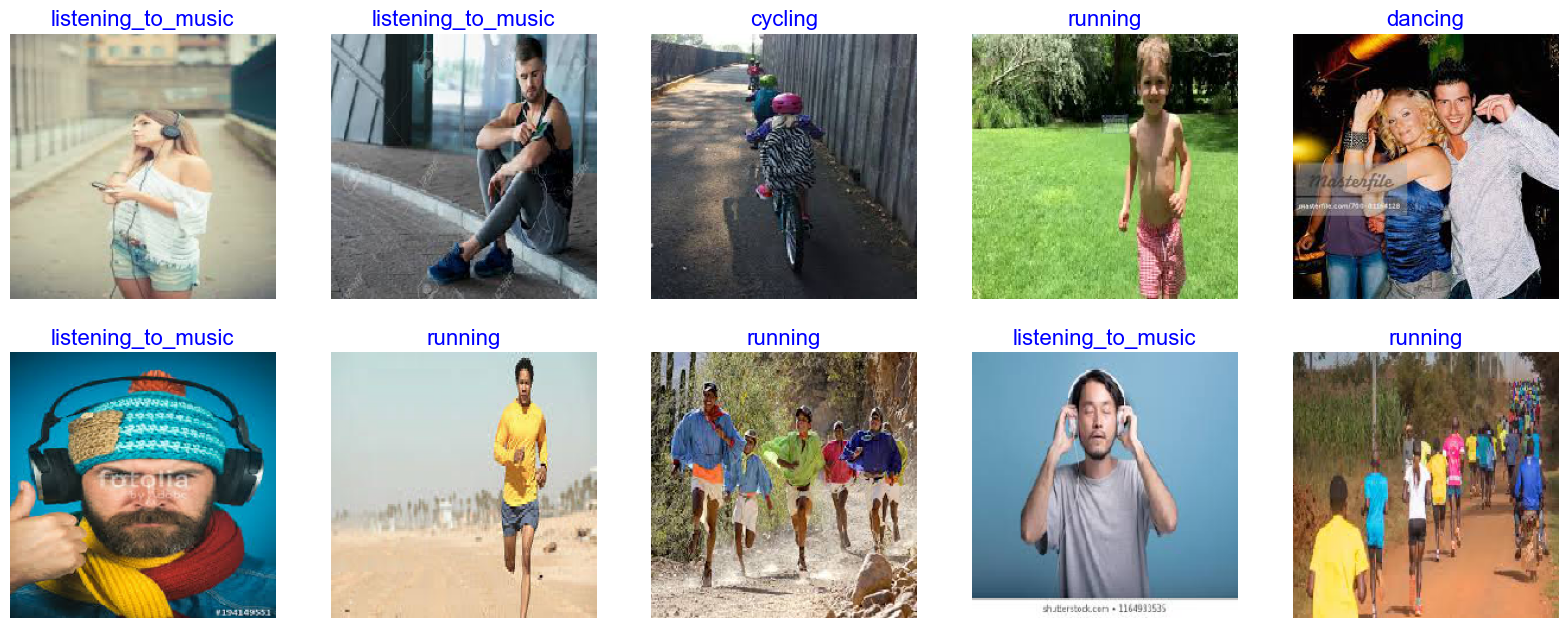

In [ ]:
def show_image_samples(gen):
    test_dict=test_gen.class_indices
    classes=list(test_dict.keys())
    images,labels=next(gen) # get a sample batch from the generator
    plt.figure(figsize=(20, 20))
    length=len(labels)
    if length<10:   #show maximum of 25 images
        r=length
    else:
        r=10
    for i in range(r):
        plt.subplot(5, 5, i + 1)
        image=(images[i]+1 )/2 # scale images between 0 and 1 becaue pre-processor set them between -1 and +1
        plt.imshow(image)
        index=np.argmax(labels[i])
        class_name=classes[index]
        plt.title(class_name, color='blue', fontsize=16)
        plt.axis('off')
    plt.show()
show_image_samples(train_gen)

In [ ]:
IMG_SIZE=224

In [ ]:
num_classes=len(classes)
print(num_classes)

6


In [ ]:
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.layers import Input
from tensorflow.keras.applications import Xception, MobileNet
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Concatenate


mobilenet = MobileNet(weights='imagenet', include_top=False)

# freeze the layers
for layer in mobilenet.layers:
    layer.trainable = False

# create a single input layer
input_layer = Input(shape=(224,224,3))

# connect the input layer to both models
x1 = mobilenet(input_layer)

# concatenate the outputs from both models
concatenated = Concatenate()([x1])

# add a few dense layers for the final prediction
flat = Flatten()(concatenated)
dense = Dense(units=1024, activation='relu')(flat)
dense = Dense(512, activation='relu')(dense)
dense = Dense(units=256, activation='relu')(dense)
predictions = Dense(num_classes, activation='softmax')(dense)
# compile the model
# this is the model we will train
model = Model(inputs=input_layer, outputs=predictions)

<ipython-input-12-742c1a13c65e>:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNet(weights='imagenet', include_top=False)


In [ ]:
x1


<KerasTensor shape=(None, 7, 7, 1024), dtype=float32, sparse=False, name=keras_tensor_171>

In [ ]:
model.compile(Adam(learning_rate=.001), loss='categorical_crossentropy', metrics=['accuracy', Precision(), Recall(), AUC(), 'mae', 'mse', RootMeanSquaredError()])

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenet_1.00_224 (Functional)      │ (None, 7, 7, 1024)          │       3,228,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ concatenate (Concatenate)            │ (None, 7, 7, 1024)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 50176)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1024)                │      51,381,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 6)                   │           1,542 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 55,267,782 (210.83 MB)

 Trainable params: 52,038,918 (198.51 MB)

 Non-trainable params: 3,228,864 (12.32 MB)

In [ ]:
model_name='MobileNet'
from tensorflow.python.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor= 'val_loss', patience=15,mode = 'min' ,verbose=1)
def print_in_color(txt_msg,fore_tupple,back_tupple,):
    rf,gf,bf=fore_tupple
    rb,gb,bb=back_tupple
    msg='{0}' + txt_msg
    mat='\33[38;2;' + str(rf) +';' + str(gf) + ';' + str(bf) + ';48;2;' + str(rb) + ';' +str(gb) + ';' + str(bb) +'m'
    print(msg .format(mat), flush=True)
    print('\33[0m', flush=True)
    return

In [ ]:
class LRA(keras.callbacks.Callback):
    reset = False
    count = 0
    stop_count = 0
    tepochs = 0
    best_weights = None

    def __init__(self, model, patience, stop_patience, threshold, factor, dwell, model_name, freeze, initial_epoch):
        super(LRA, self).__init__()
        self._model = model
        self.patience = patience
        self.stop_patience = stop_patience
        self.threshold = threshold
        self.factor = factor
        self.dwell = dwell
        self.lr = float(tf.keras.backend.get_value(model.optimizer.learning_rate))
        self.highest_tracc = 0.0
        self.lowest_vloss = np.inf
        self.initial_epoch = initial_epoch
        LRA.best_weights = model.get_weights()

        msgs = (f' Starting training using base model {model_name} with weights frozen to imagenet weights initializing LRA callback'
                if freeze else
                f' Starting training using base model {model_name} training all layers ')
        print_in_color(msgs, (244, 252, 3), (55,65,80))

    @property
    def model(self):
        return self._model

    @model.setter
    def model(self, value):
        self._model = value

    def on_epoch_begin(self, epoch, logs=None):
        self.now = time.time()

    def on_epoch_end(self, epoch, logs=None):
        later = time.time()
        duration = later - self.now

        if epoch == self.initial_epoch or LRA.reset:
            LRA.reset = False
            msg = '{0:^8s}{1:^10s}{2:^9s}{3:^9s}{4:^9s}{5:^9s}{6:^9s}'.format(
                'Epoch', 'Loss', 'Acc', 'V_loss', 'V_acc', 'LR', 'Next LR'
            )
            print_in_color(msg, (244,252,3), (55,65,80))

        lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
        current_lr = lr
        v_loss = logs.get('val_loss')
        acc = logs.get('accuracy')
        v_acc = logs.get('val_accuracy')
        loss = logs.get('loss')

        if acc < self.threshold:
            if acc > self.highest_tracc:
                self.highest_tracc = acc
                LRA.best_weights = self.model.get_weights()
                self.count = 0
                self.stop_count = 0
                if v_loss < self.lowest_vloss:
                    self.lowest_vloss = v_loss
                self.lr = lr
            else:
                if self.count >= self.patience - 1:
                    self.lr = lr * self.factor
                    tf.keras.backend.set_value(self.model.optimizer.learning_rate, self.lr)
                    self.count = 0
                    self.stop_count += 1
                    if self.dwell:
                        self.model.set_weights(LRA.best_weights)
                else:
                    self.count += 1

        else:
            if v_loss < self.lowest_vloss:
                self.lowest_vloss = v_loss
                LRA.best_weights = self.model.get_weights()
                self.count = 0
                self.stop_count = 0
                self.lr = lr
            else:
                if self.count >= self.patience - 1:
                    self.lr = self.lr * self.factor
                    self.stop_count += 1
                    self.count = 0
                    tf.keras.backend.set_value(self.model.optimizer.learning_rate, self.lr)
                    if self.dwell:
                        self.model.set_weights(LRA.best_weights)
                else:
                    self.count += 1

        # Print training progress
        msg = f'{str(epoch+1):^3s}/{str(LRA.tepochs):4s} {loss:^9.3f}{acc:^9.3f}{v_loss:^9.3f}{v_acc:^9.3f}{current_lr:^9.5f}{self.lr:^9.5f}'
        print_in_color(msg, (0, 67, 54), (55,65,80))

        if self.stop_count > self.stop_patience - 1:
            msg = f' training has been halted at epoch {epoch + 1} after {self.stop_patience} adjustments of learning rate with no improvement'
            print_in_color(msg, (0,255,0), (55,65,80))
            self.model.stop_training = True

def print_in_color(txt, fore_color, back_color):
    print(f'\033[38;2;{fore_color[0]};{fore_color[1]};{fore_color[2]}m\033[48;2;{back_color[0]};{back_color[1]};{back_color[2]}m{txt}\033[0m')

# Define freeze before using it
freeze = False

model = tf.keras.applications.MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
model.trainable = not freeze

model = tf.keras.Sequential([
    model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(len(classes), activation='softmax')
])
model = tf.keras.applications.MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
model.trainable = not freeze

model = tf.keras.Sequential([
    model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(len(classes), activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

epochs = 5
patience = 2
stop_patience = 2
threshold = 0.8
factor = 0.8
dwell = True
freeze = False

callbacks = [LRA(model=model,
                patience=patience,
                stop_patience=stop_patience,
                threshold=threshold,
                factor=factor,
                dwell=dwell,
                model_name='MobileNet',
                freeze=freeze,
                initial_epoch=0)]

LRA.tepochs = epochs
history = model.fit(x=train_gen,
                   epochs=epochs,
                   callbacks=callbacks,
                   verbose=1,
                   validation_data=valid_gen,
                   validation_steps=None,
                   shuffle=False,
                   initial_epoch=0)

 Starting training using base model MobileNet training all layers 
Epoch 1/5


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.6591 - loss: 0.9412 Epoch     Loss      Acc    V_loss    V_acc     LR     Next LR 
 1 /5      0.612    0.784    0.476    0.832   0.00010  0.00010 
143/143 ━━━━━━━━━━━━━━━━━━━━ 997s 7s/step - accuracy: 0.6600 - loss: 0.9389 - val_accuracy: 0.8322 - val_loss: 0.4764
Epoch 2/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9673 - loss: 0.1399 2 /5      0.133    0.967    0.378    0.864   0.00010  0.00010 
143/143 ━━━━━━━━━━━━━━━━━━━━ 927s 6s/step - accuracy: 0.9673 - loss: 0.1398 - val_accuracy: 0.8636 - val_loss: 0.3784
Epoch 3/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9919 - loss: 0.0534 3 /5      0.054    0.991    0.341    0.888   0.00010  0.00010 
143/143 ━━━━━━━━━━━━━━━━━━━━ 922s 6s/step - accuracy: 0.9919 - loss: 0.0535 - val_accuracy: 0.8881 - val_loss: 0.3407
Epoch 4/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9995 - loss: 0.0241 4 /5      0.024    0.998    0.309    0.893   0.00010  0.00010 
143/

In [ ]:
def tr_plot(tr_data, start_epoch):
    #Plot the training and validation data
    tacc=tr_data.history['accuracy']
    tloss=tr_data.history['loss']
    vacc=tr_data.history['val_accuracy']
    vloss=tr_data.history['val_loss']
    Epoch_count=len(tacc)+ start_epoch
    Epochs=[]
    for i in range (start_epoch ,Epoch_count):
        Epochs.append(i+1)
    index_loss=np.argmin(vloss)#  this is the epoch with the lowest validation loss
    val_lowest=vloss[index_loss]
    index_acc=np.argmax(vacc)
    acc_highest=vacc[index_acc]
    plt.style.use('fivethirtyeight')
    sc_label='best epoch= '+ str(index_loss+1 +start_epoch)
    vc_label='best epoch= '+ str(index_acc + 1+ start_epoch)
    fig,axes=plt.subplots(nrows=1, ncols=2, figsize=(20,8))
    axes[0].plot(Epochs,tloss, 'r', label='Training loss')
    axes[0].plot(Epochs,vloss,'g',label='Validation loss' )
    axes[0].scatter(index_loss+1 +start_epoch,val_lowest, s=150, c= 'blue', label=sc_label)
    axes[0].set_title('Training and Validation Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[1].plot (Epochs,tacc,'r',label= 'Training Accuracy')
    axes[1].plot (Epochs,vacc,'g',label= 'Validation Accuracy')
    axes[1].scatter(index_acc+1 +start_epoch,acc_highest, s=150, c= 'blue', label=vc_label)
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    plt.tight_layout
    #plt.style.use('fivethirtyeight')
    plt.show()

In [ ]:
def print_info( test_gen, preds, print_code, save_dir, subject ):
    class_dict=test_gen.class_indices
    labels= test_gen.labels
    file_names= test_gen.filenames
    error_list=[]
    true_class=[]
    pred_class=[]
    prob_list=[]
    new_dict={}
    error_indices=[]
    y_pred=[]
    for key,value in class_dict.items():
        new_dict[value]=key             # dictionary {integer of class number: string of class name}
    # store new_dict as a text fine in the save_dir
    classes=list(new_dict.values())     # list of string of class names
    dict_as_text=str(new_dict)
    dict_name= subject + '-' +str(len(classes)) +'.txt'
    dict_path=os.path.join(save_dir,dict_name)
    with open(dict_path, 'w') as x_file:
        x_file.write(dict_as_text)
    errors=0
    for i, p in enumerate(preds):
        pred_index=np.argmax(p)
        true_index=labels[i]  # labels are integer values
        if pred_index != true_index: # a misclassification has occurred
            error_list.append(file_names[i])
            true_class.append(new_dict[true_index])
            pred_class.append(new_dict[pred_index])
            prob_list.append(p[pred_index])
            error_indices.append(true_index)
            errors=errors + 1
        y_pred.append(pred_index)
    if print_code !=0:
        if errors>0:
            if print_code>errors:
                r=errors
            else:
                r=print_code
            msg='{0:^28s}{1:^28s}{2:^28s}{3:^16s}'.format('Filename', 'Predicted Class' , 'True Class', 'Probability')
            print_in_color(msg, (0,255,0),(55,65,80))
            for i in range(r):
                split1=os.path.split(error_list[i])
                split2=os.path.split(split1[0])
                fname=split2[1] + '/' + split1[1]
                msg='{0:^28s}{1:^28s}{2:^28s}{3:4s}{4:^6.4f}'.format(fname, pred_class[i],true_class[i], ' ', prob_list[i])
                print_in_color(msg, (255,255,255), (55,65,60))
                #print(error_list[i]  , pred_class[i], true_class[i], prob_list[i])
        else:
            msg='With accuracy of 100 % there are no errors to print'
            print_in_color(msg, (0,255,0),(55,65,80))
    if errors>0:
        plot_bar=[]
        plot_class=[]
        for  key, value in new_dict.items():
            count=error_indices.count(key)
            if count!=0:
                plot_bar.append(count) # list containg how many times a class c had an error
                plot_class.append(value)   # stores the class
        fig=plt.figure()
        fig.set_figheight(len(plot_class)/3)
        fig.set_figwidth(10)
        plt.style.use('fivethirtyeight')
        for i in range(0, len(plot_class)):
            c=plot_class[i]
            x=plot_bar[i]
            plt.barh(c, x, )
            plt.title( ' Errors by Class on Test Set')
    y_true= np.array(labels)
    y_pred=np.array(y_pred)
    if len(classes)<= 30:
        # create a confusion matrix
        cm = confusion_matrix(y_true, y_pred )
        length=len(classes)
        if length<8:
            fig_width=8
            fig_height=8
        else:
            fig_width= int(length * .5)
            fig_height= int(length * .5)
        plt.figure(figsize=(fig_width, fig_height))
        sns.heatmap(cm, annot=True, vmin=0, fmt='g', cmap='Blues', cbar=False)
        plt.xticks(np.arange(length)+.5, classes, rotation= 90)
        plt.yticks(np.arange(length)+.5, classes, rotation=0)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()
    clr = classification_report(y_true, y_pred, target_names=classes)
    print("Classification Report:\n----------------------\n", clr)

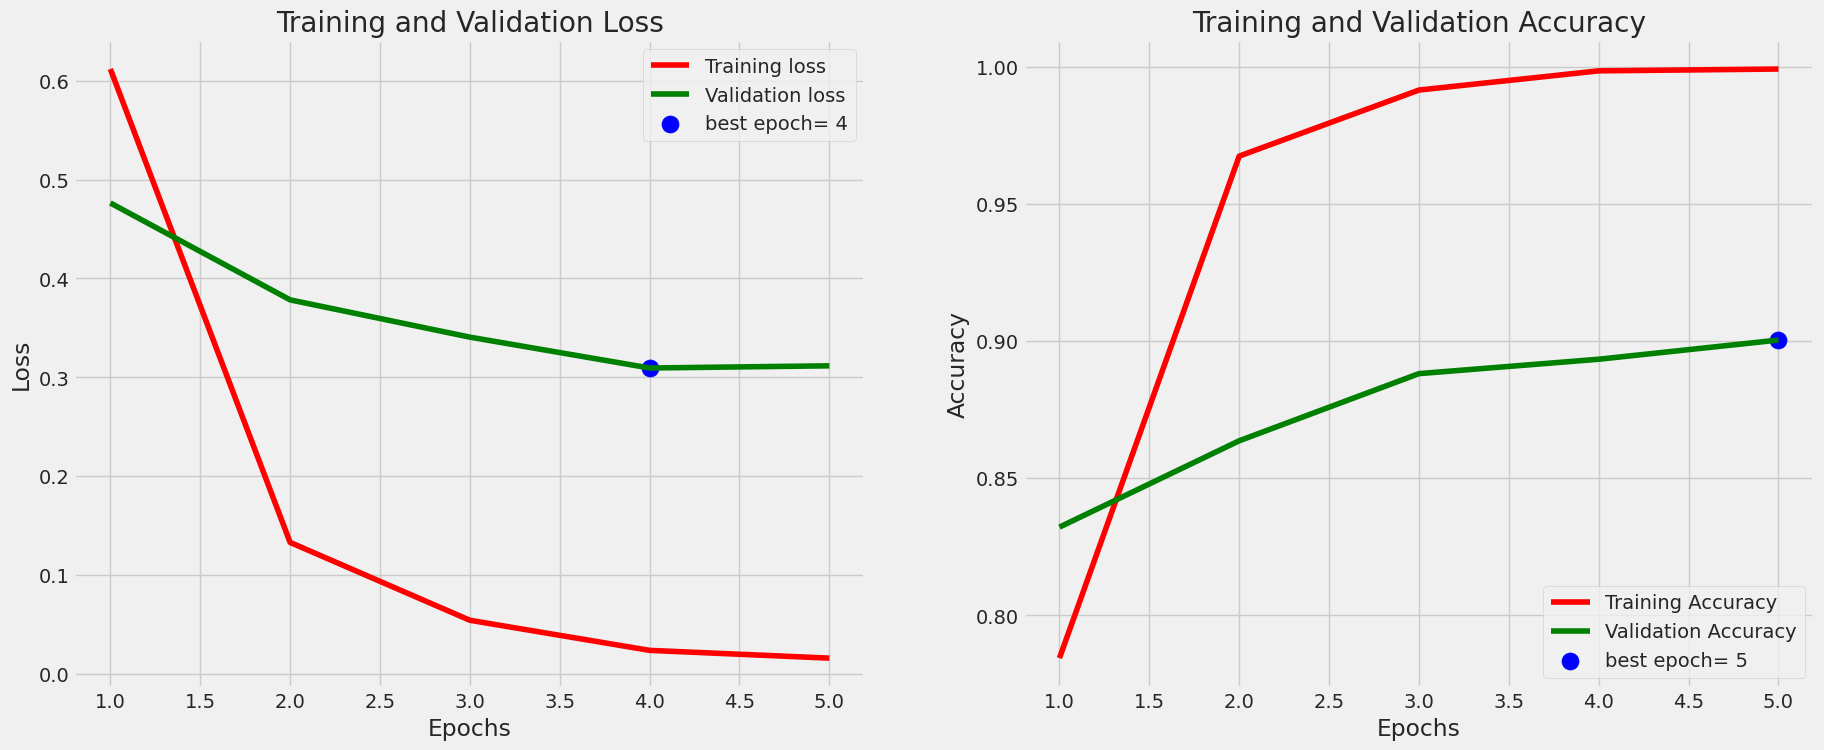

  2/571 ━━━━━━━━━━━━━━━━━━━━ 39s 70ms/step - accuracy: 1.0000 - loss: 7.8114e-04  

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


571/571 ━━━━━━━━━━━━━━━━━━━━ 95s 165ms/step - accuracy: 0.8987 - loss: 0.3128


accuracy on the test set is 88.44 %


In [ ]:
tr_plot(history,0)
save_dir=r'./'
subject='fruits'
acc=model.evaluate( test_gen, batch_size=test_batch_size, verbose=1, steps=test_steps, return_dict=False)[1]*100
msg=f'accuracy on the test set is {acc:5.2f} %'
print_in_color(msg, (0,255,0),(55,65,80))
save_id=str (model_name +  '-' + subject +'-'+ str(acc)[:str(acc).rfind('.')+3] + '.h5')
save_loc=os.path.join(save_dir, save_id)
model.save(save_loc)

571/571 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step


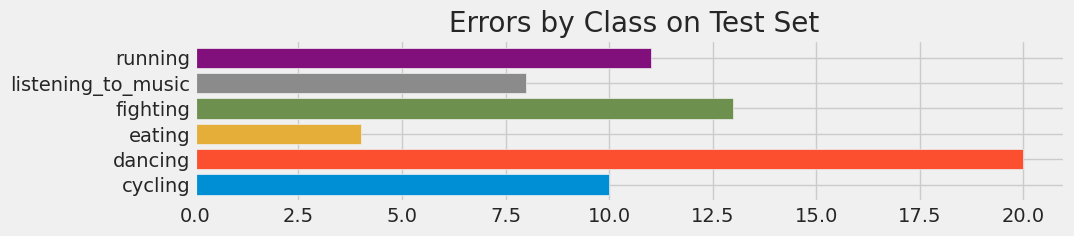

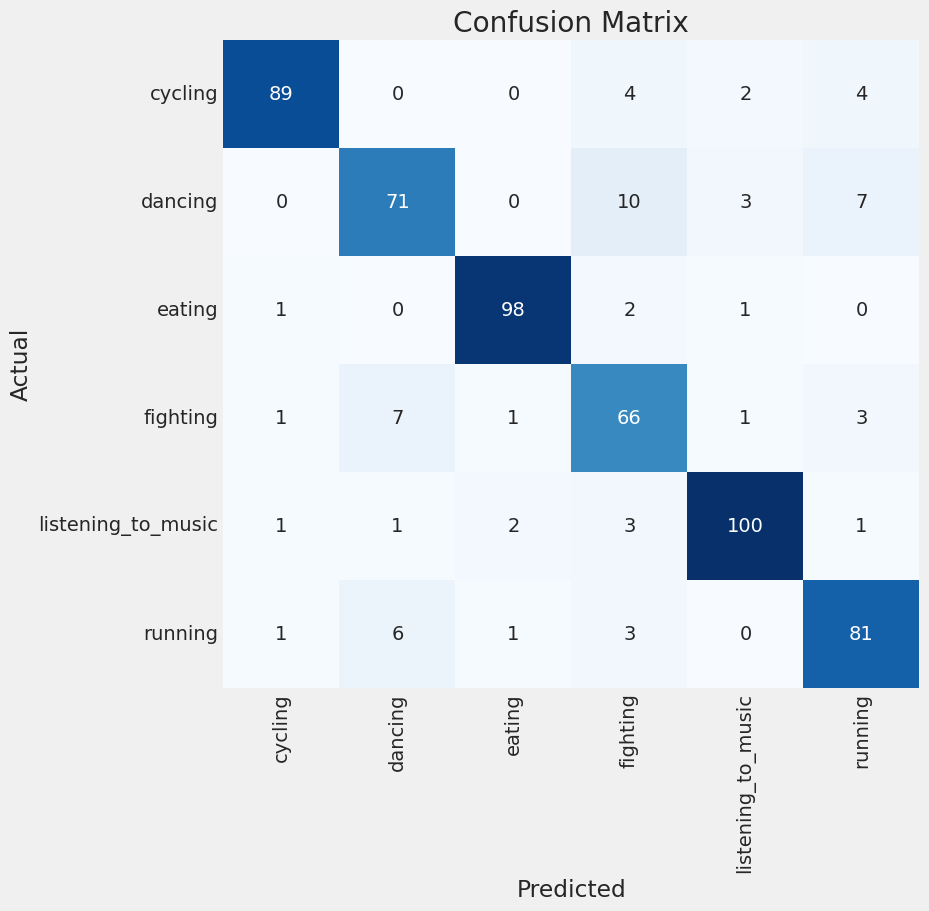

Classification Report:
----------------------
                     precision    recall  f1-score   support

           cycling       0.96      0.90      0.93        99
           dancing       0.84      0.78      0.81        91
            eating       0.96      0.96      0.96       102
          fighting       0.75      0.84      0.79        79
listening_to_music       0.93      0.93      0.93       108
           running       0.84      0.88      0.86        92

          accuracy                           0.88       571
         macro avg       0.88      0.88      0.88       571
      weighted avg       0.89      0.88      0.89       571



In [ ]:
print_code=0
preds=model.predict(test_gen)
print_info( test_gen, preds, print_code, save_dir, subject )

In [ ]:
from tensorflow.keras.applications import Xception, ResNet50
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Concatenate, Flatten, Dense
from tensorflow.keras.models import Model

# Tải ResNet50 với các trọng số pre-trained trên ImageNet
resnet50 = ResNet50(weights='imagenet', include_top=False)

# Đóng băng các lớp trong cả hai mô hình
for layer in resnet50.layers:
    layer.trainable = False

# Tạo một input layer duy nhất
input_layer = Input(shape=(224, 224, 3))

# Kết nối input layer với ResNet50 và Xception
x1 = resnet50(input_layer)

# Kết hợp (concatenate) đầu ra của hai mô hình
concatenated = Concatenate()([x1])

# Thêm các lớp Dense để thực hiện dự đoán
flat = Flatten()(concatenated)
dense = Dense(units=1024, activation='relu')(flat)
dense = Dense(units=512, activation='relu')(dense)
dense = Dense(units=256, activation='relu')(dense)
num_classes = 6  # Số lượng lớp (bạn có thể thay đổi)
predictions = Dense(num_classes, activation='softmax')(dense)

# Tạo mô hình
model = Model(inputs=input_layer, outputs=predictions)

# Biên dịch mô hình
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# In kiến trúc mô hình
model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ concatenate (Concatenate)       │ (None, 7, 7, 2048)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │   102,761,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,006,854 (484.49 MB)

 Trainable params: 103,419,142 (394.51 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
x1

<KerasTensor shape=(None, 7, 7, 2048), dtype=float32, sparse=False, name=keras_tensor_349>

In [ ]:
model_name='Resnet'

Starting training using base model ResNet50 training all layers

Epoch 1/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7160 - loss: 0.8022 Epoch     Loss      Acc    V_loss    V_acc     LR     Next LR 

 1 /5      0.533    0.814    2.345    0.184   0.00010  0.00010 

143/143 ━━━━━━━━━━━━━━━━━━━━ 844s 6s/step - accuracy: 0.7167 - loss: 0.8003 - val_accuracy: 0.1836 - val_loss: 2.3448
Epoch 2/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9805 - loss: 0.0797 2 /5      0.073    0.980    2.483    0.267   0.00010  0.00010 

143/143 ━━━━━━━━━━━━━━━━━━━━ 811s 6s/step - accuracy: 0.9805 - loss: 0.0797 - val_accuracy: 0.2675 - val_loss: 2.4826
Epoch 3/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9970 - loss: 0.0181 3 /5      0.022    0.994    2.170    0.397   0.00010  0.00010 

143/143 ━━━━━━━━━━━━━━━━━━━━ 862s 6s/step - accuracy: 0.9970 - loss: 0.0181 - val_accuracy: 0.3969 - val_loss: 2.1696
Epoch 4/5
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9976 - l

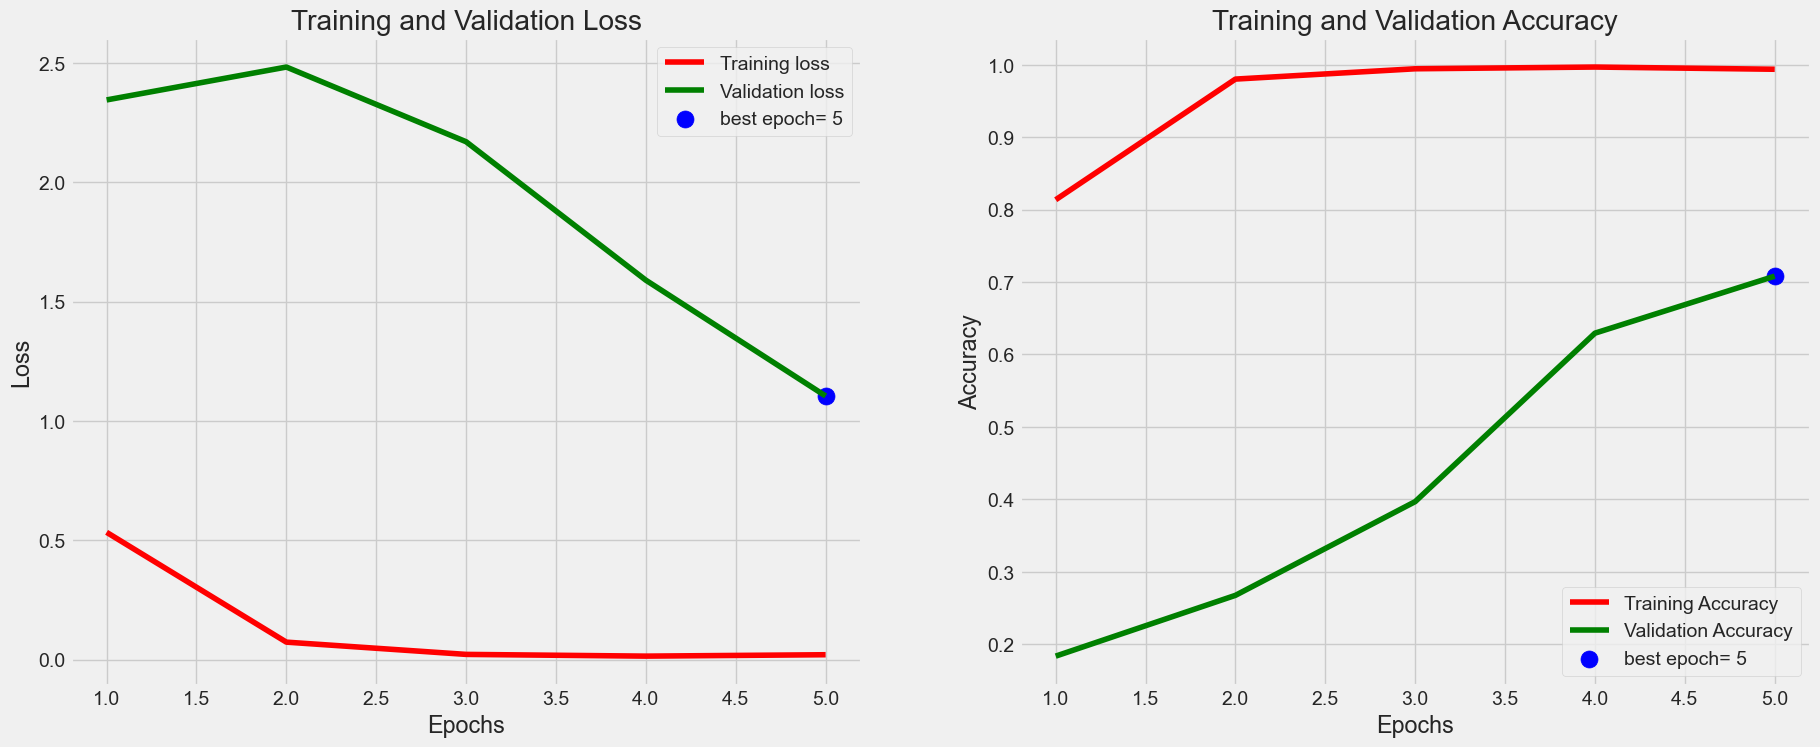

E:\Anaconda_Navigator\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


571/571 ━━━━━━━━━━━━━━━━━━━━ 41s 71ms/step - accuracy: 0.7666 - loss: 0.8044
accuracy on the test set is 74.61 %



571/571 ━━━━━━━━━━━━━━━━━━━━ 42s 71ms/step


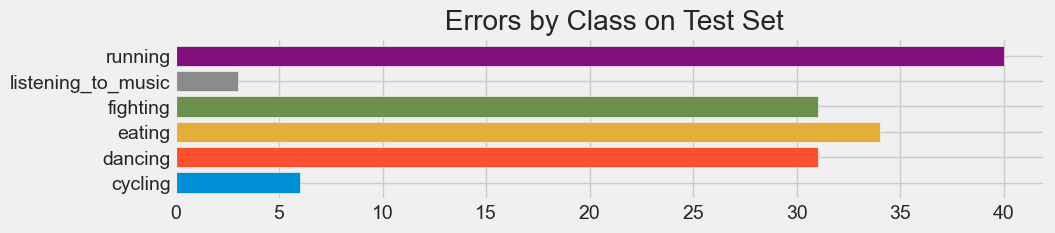

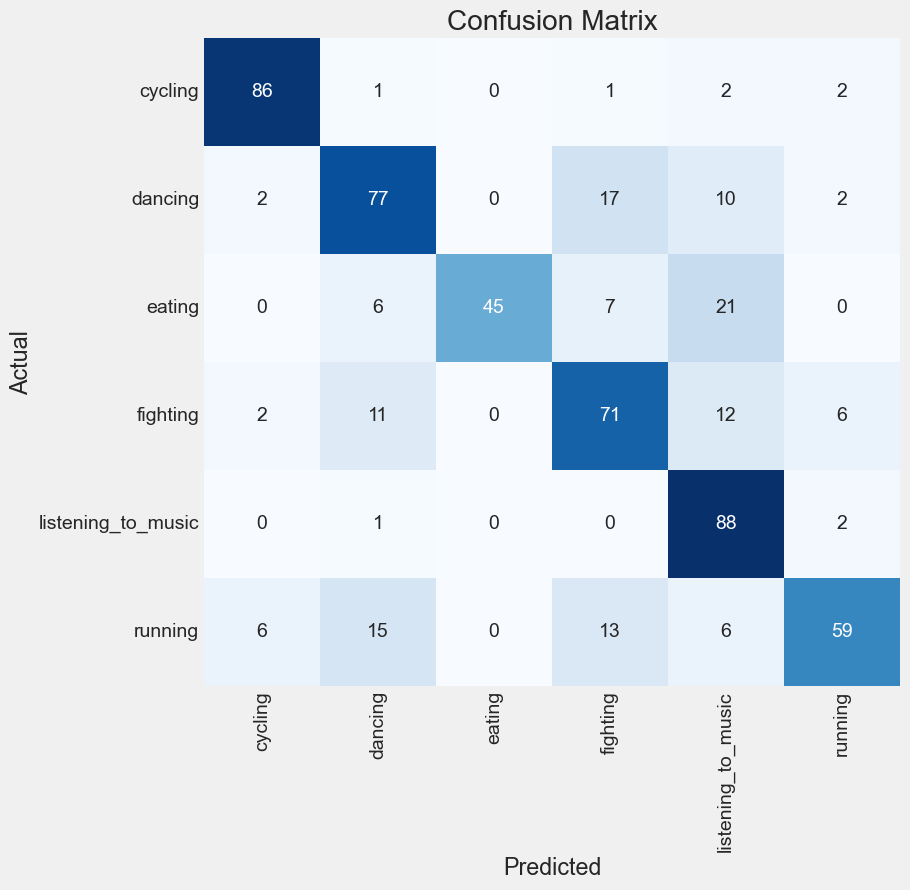

Classification Report:
----------------------
                     precision    recall  f1-score   support

           cycling       0.90      0.93      0.91        92
           dancing       0.69      0.71      0.70       108
            eating       1.00      0.57      0.73        79
          fighting       0.65      0.70      0.67       102
listening_to_music       0.63      0.97      0.77        91
           running       0.83      0.60      0.69        99

          accuracy                           0.75       571
         macro avg       0.78      0.75      0.75       571
      weighted avg       0.78      0.75      0.74       571



In [ ]:
# Define freeze before using it
freeze = False

# Create ResNet model
base_model = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = not freeze

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(len(classes), activation='softmax')
])

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Training parameters
epochs = 5
patience = 2
stop_patience = 2
threshold = 0.8
factor = 0.8
dwell = True
freeze = False

# Callbacks
callbacks = [LRA(model=model,
                  patience=patience,
                  stop_patience=stop_patience,
                  threshold=threshold,
                  factor=factor,
                  dwell=dwell,
                  model_name='ResNet50',
                  freeze=freeze,
                  initial_epoch=0)]

LRA.tepochs = epochs

# Fit the model
history = model.fit(x=train_gen,
                    epochs=epochs,
                    callbacks=callbacks,
                    verbose=1,
                    validation_data=valid_gen,
                    validation_steps=None,
                    shuffle=False,
                    initial_epoch=0)
tr_plot(history,0)
save_dir=r'./'
subject='fruits'
acc=model.evaluate( test_gen, batch_size=test_batch_size, verbose=1, steps=test_steps, return_dict=False)[1]*100
msg=f'accuracy on the test set is {acc:5.2f} %'
print_in_color(msg, (0,255,0),(55,65,80))
save_id=str (model_name +  '-' + subject +'-'+ str(acc)[:str(acc).rfind('.')+3] + '.h5')
save_loc=os.path.join(save_dir, save_id)
model.save(save_loc)
print_code=0
preds=model.predict(test_gen)
print_info( test_gen, preds, print_code, save_dir, subject )